# TUTORIAL: Class ESN_model

The class `ESN_model` defined in `src.models_datadriven` and it combines the classes `EchoStateNetwork`, from `tools_ML.EchoStateNetwork`, and `Model` `from model`.



In [2]:
from models_data_driven import ESN_model


## Initialisation 
To create a any model from `models_datadriven` we need some data to learn. Let's use the Lorenz 63 again.

Loaded case


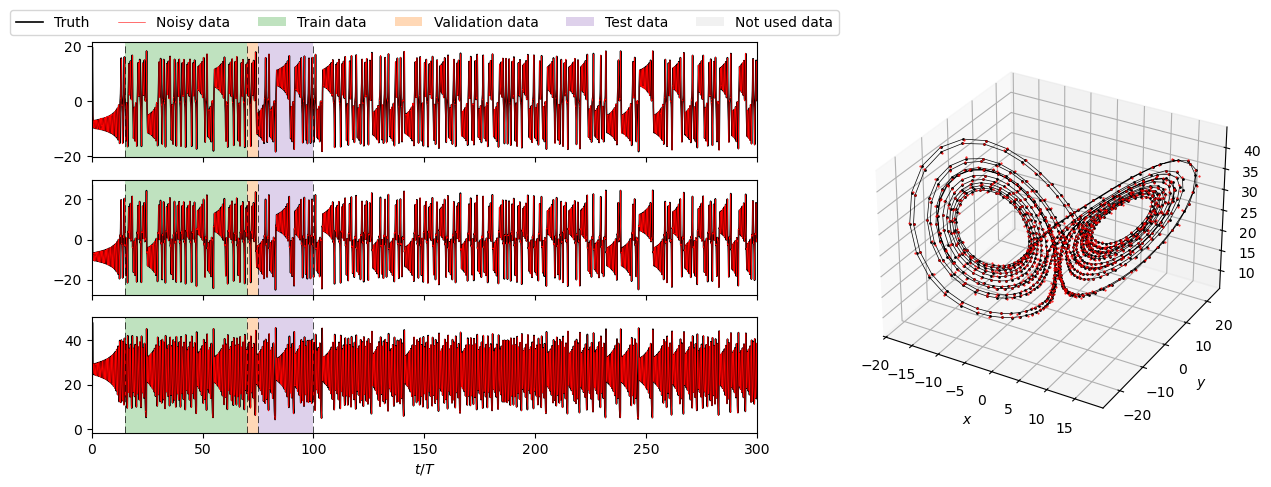

In [2]:
from plotting import plot_train_dataset
from utils import create_Lorenz63_dataset

dataset = create_Lorenz63_dataset(noise_level=0.02, 
                                  num_lyap_times=300)


clean_data, noisy_data, t, N_lyap = [dataset[key] for key in ['clean_data', 'noisy_data', 
                                                              't', 'N_lyap']]

dt = t[1] - t[0]
t_lyap = N_lyap * dt


# Split the dataset 
N_transient = 15 * N_lyap
N_val = 5 * N_lyap
N_train = 60 * N_lyap - N_val 
N_test = 5 * N_val


# Visualize
split_times = [tt / N_lyap for tt in [N_transient, N_train, N_val, N_test]]
plot_train_dataset(clean_data, noisy_data, t/t_lyap, *split_times)


 ----------------- HYPERPARAMETER SEARCH ------------------
 4x4 grid and 4 points with Bayesian Optimization
		 rho	 sigma_in	 tikh	 MSE val 
1	 2.000e-01	 5.000e-01	 1.000e-06	 2.4312
2	 2.000e-01	 2.321e+00	 1.000e-06	 -0.4777
3	 2.000e-01	 1.077e+01	 1.000e-06	 -0.9088
4	 2.000e-01	 5.000e+01	 1.000e-06	 -0.8437
5	 4.000e-01	 5.000e-01	 1.000e-06	 2.2340
6	 4.000e-01	 2.321e+00	 1.000e-06	 -0.9467
7	 4.000e-01	 1.077e+01	 1.000e-06	 -1.0497
8	 4.000e-01	 5.000e+01	 1.000e-06	 -0.7879
9	 6.000e-01	 5.000e-01	 1.000e-06	 2.3477
10	 6.000e-01	 2.321e+00	 1.000e-06	 -0.8401
11	 6.000e-01	 1.077e+01	 1.000e-06	 -0.8244
12	 6.000e-01	 5.000e+01	 1.000e-12	 -0.8183
13	 8.000e-01	 5.000e-01	 1.000e-06	 0.9693
14	 8.000e-01	 2.321e+00	 1.000e-06	 -0.9739
15	 8.000e-01	 1.077e+01	 1.000e-09	 -0.8329
16	 8.000e-01	 5.000e+01	 1.000e-12	 -0.7962
17	 4.377e-01	 4.500e+00	 1.000e-06	 -0.9806
18	 3.331e-01	 2.124e+01	 1.000e-06	 -0.9070
19	 8.000e-01	 4.198e+00	 1.000e-06	 -0.9224
20	 3.623e-01	

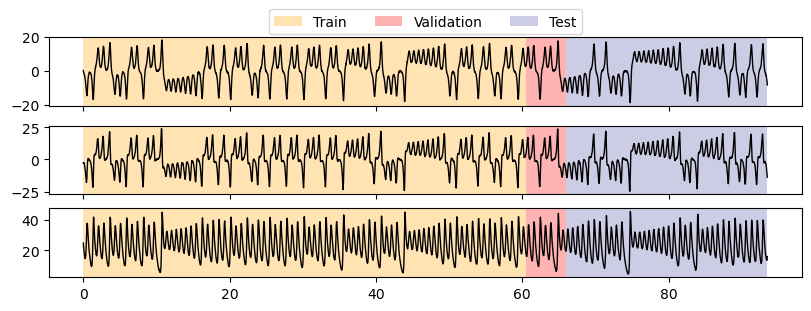

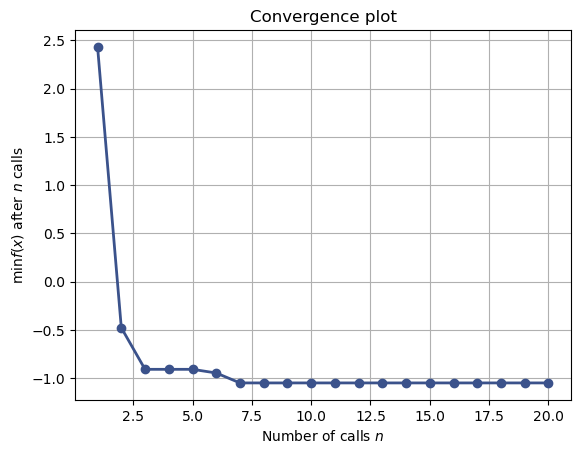

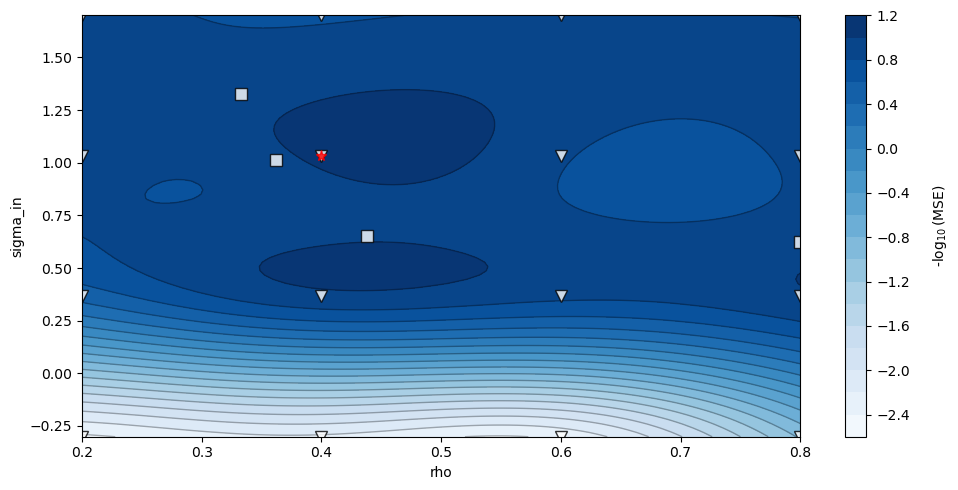

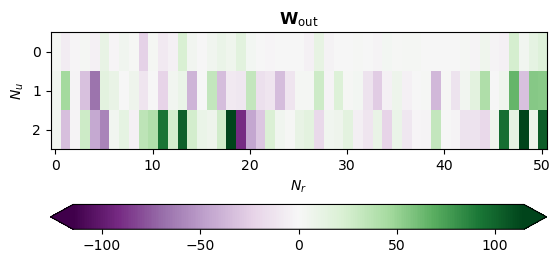

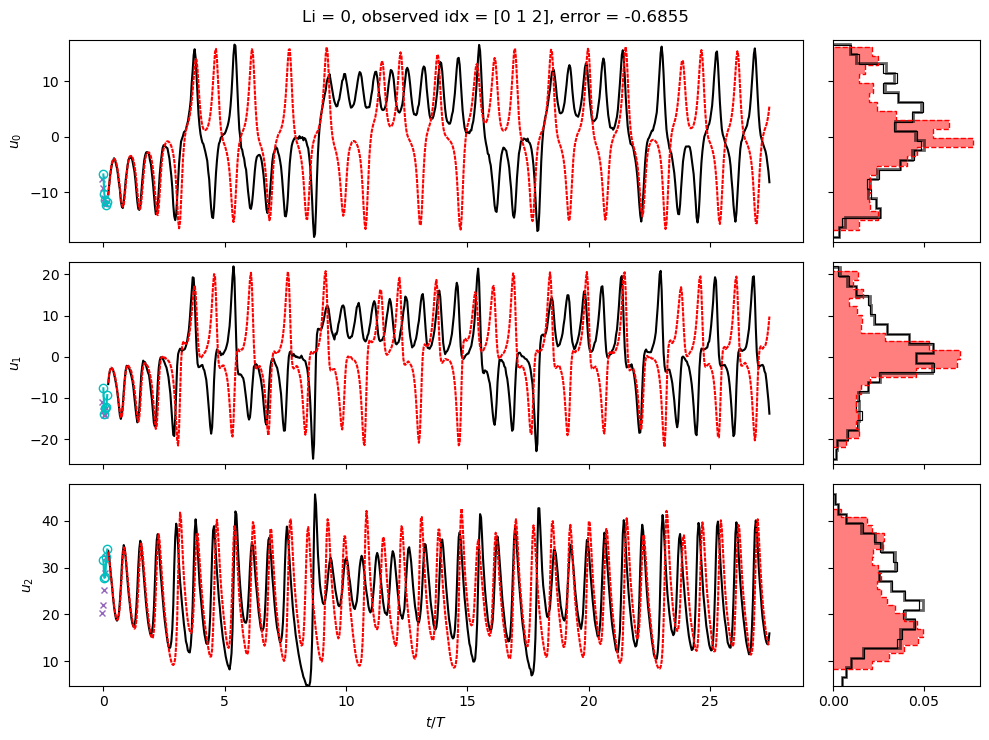

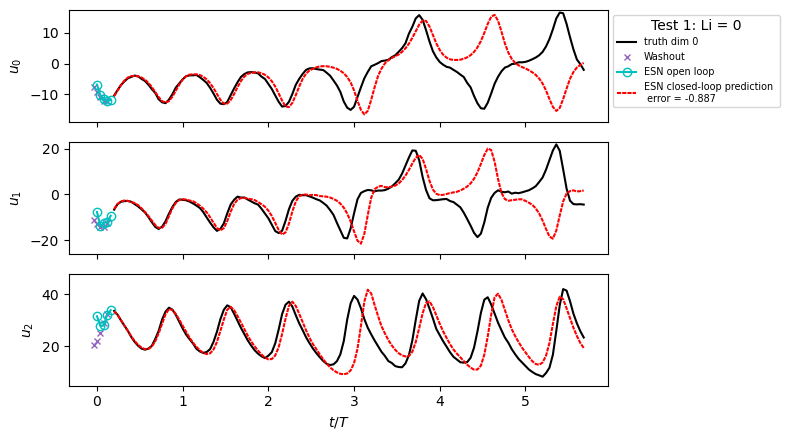

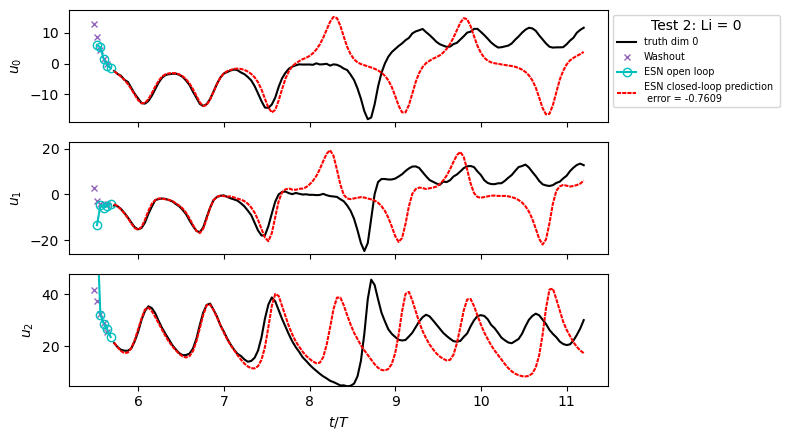

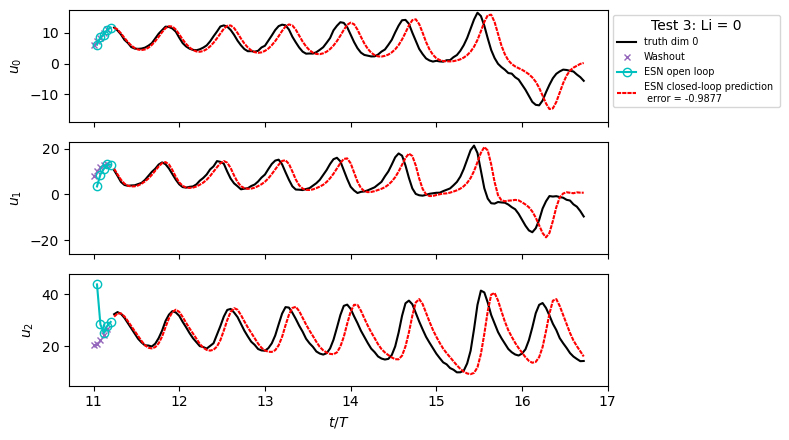

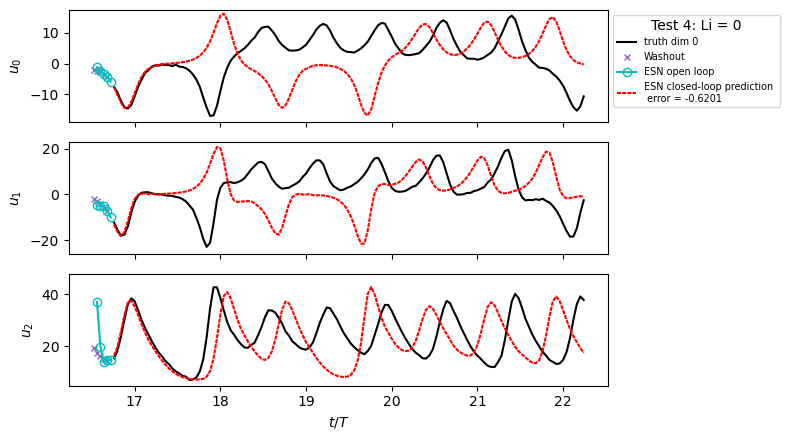

In [3]:

training_data = noisy_data[N_transient:sum([N_transient, N_train, N_val, N_test])]


model = ESN_model(data=training_data,
                N_train=N_train,
                N_val=N_val,
                N_test=N_test,
                dt=dt,
                upsample=2,
                N_folds=5,
                N_grid=4,
                N_func_evals=20,
                plot_training=True,
                )



## 2. Ensemble forecast

Modifyig settings...
dict_keys(['m', 'est_phi', 'est_alpha', 'est_bias', 'Na'])
Updated est_alpha: ['svd_0', 'svd_1', 'svd_2']
New est_alpha in config: ['svd_0', 'svd_1', 'svd_2']
Creating normal ensemble with std=0.01 for mean_vec of shape (53,) and m=10
Init ensemble history with shape: (1, 56, 10) and [0.]


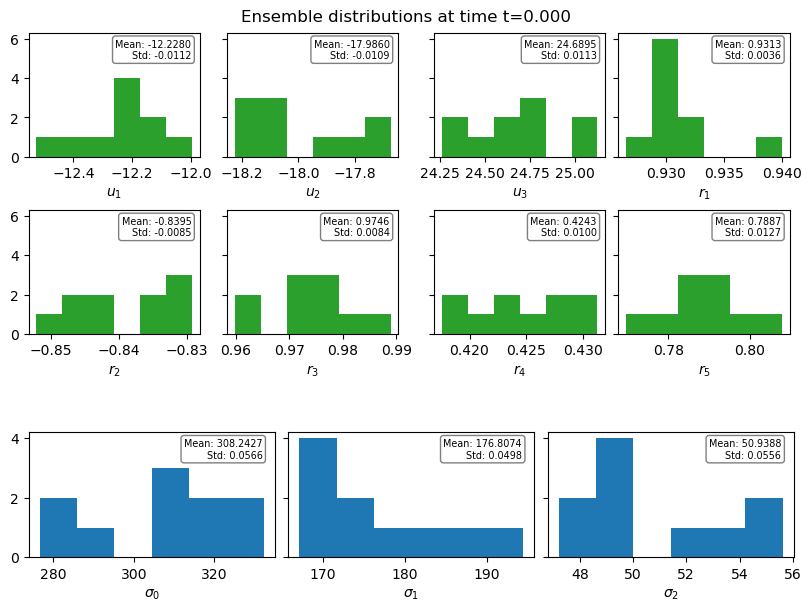

In [4]:
from ensemble import Ensemble

m = 10
ensemble = Ensemble(parent_model=model,
                    m=m, 
                    std_phi=0.01, 
                    est_alpha=['Wout'], # Select the ensemble varying parameters
                    std_alpha=0.1,  # the parameters uncertainty can also be defined individually in a dictionary
                    # alpha_distr='uniform'
                   )

ensemble.visualize_state(max_modes=6)

In [5]:
# from plot_results import plot_obs_timeseries, plot_parameters
for _ in range(5):
    t = ensemble.current_time + 2*t_lyap
    ensemble.forecast_step(t_end=t)  



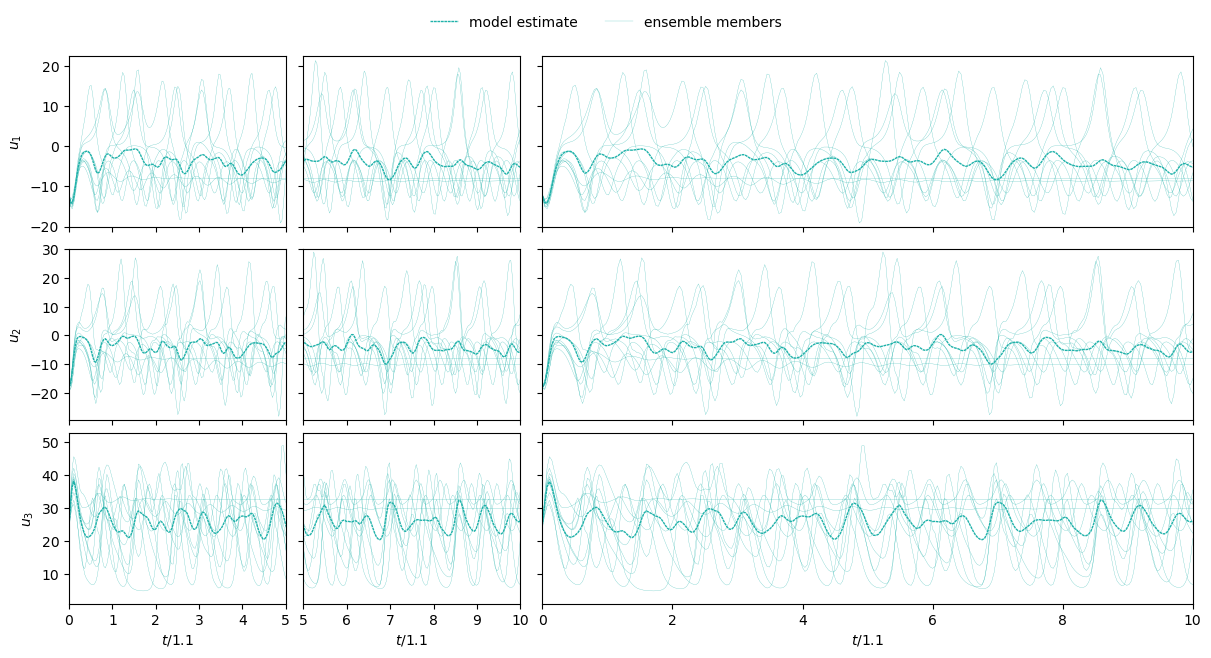

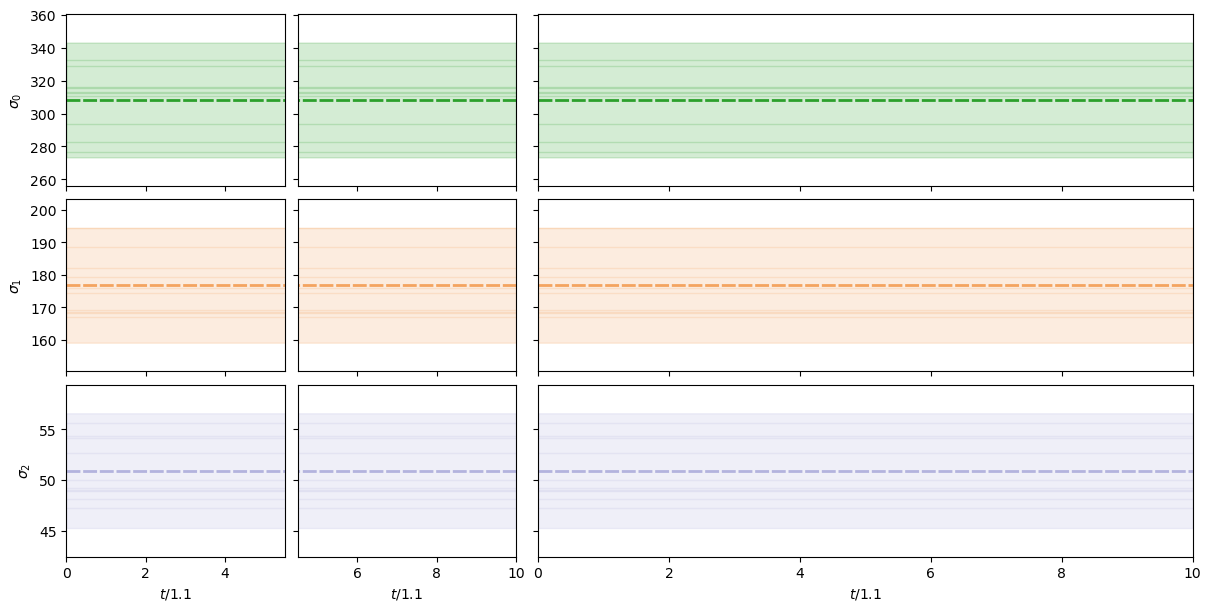

In [6]:
ensemble.visualize_history(plot_members=True, reference_t=t_lyap)

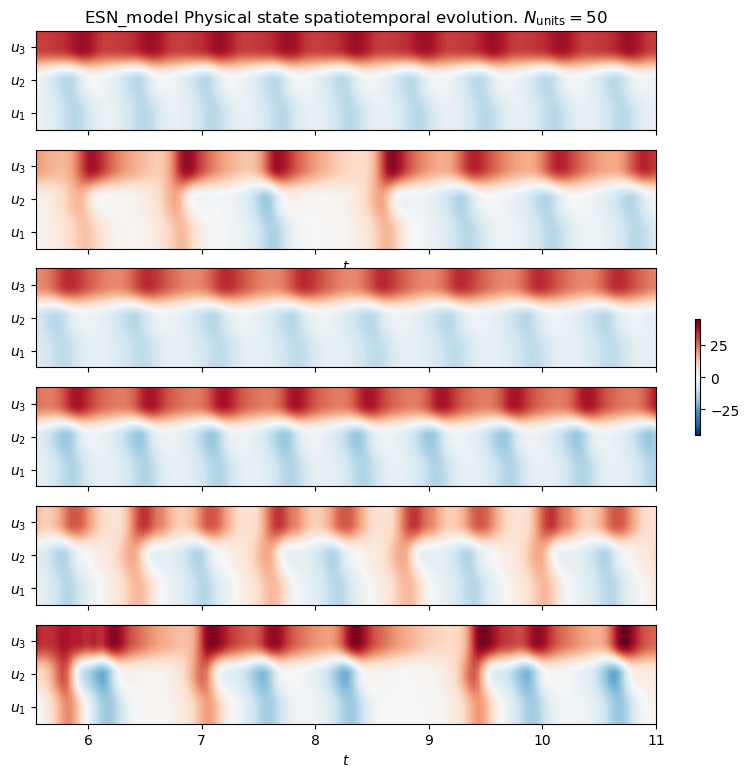

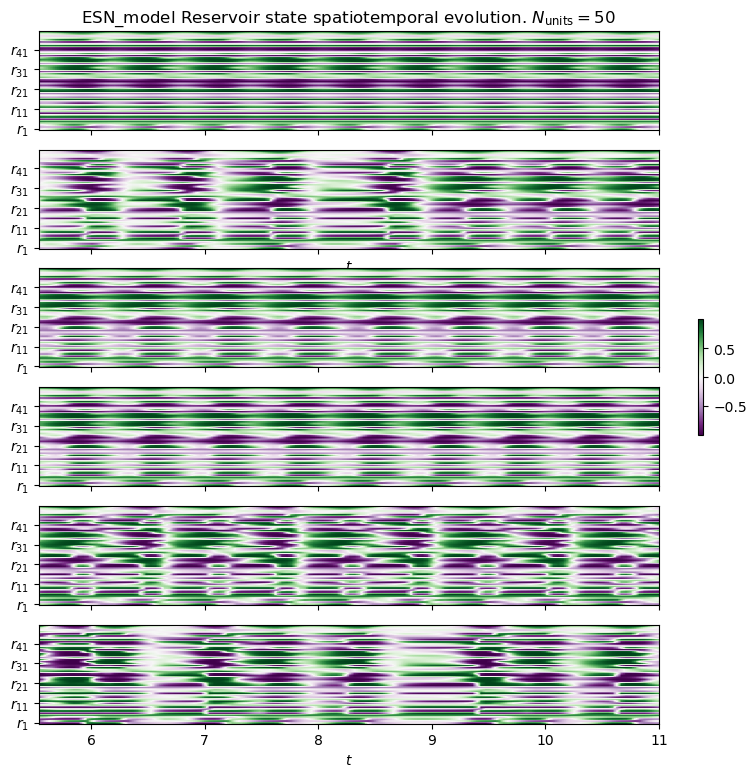

In [7]:
ensemble.model.visualize_spatiotemporal_hist(averaged=False, nrows=6)

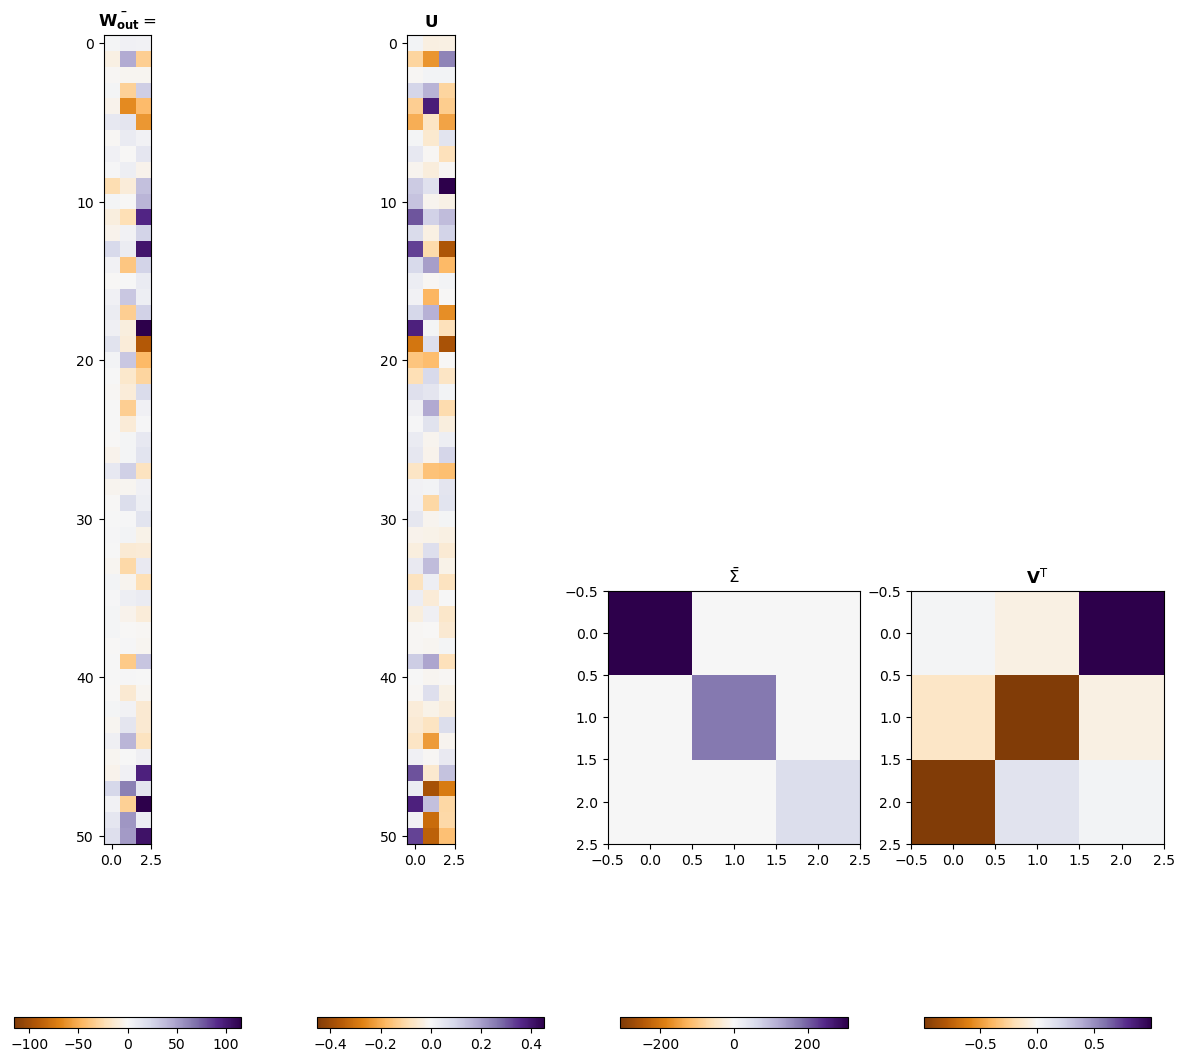

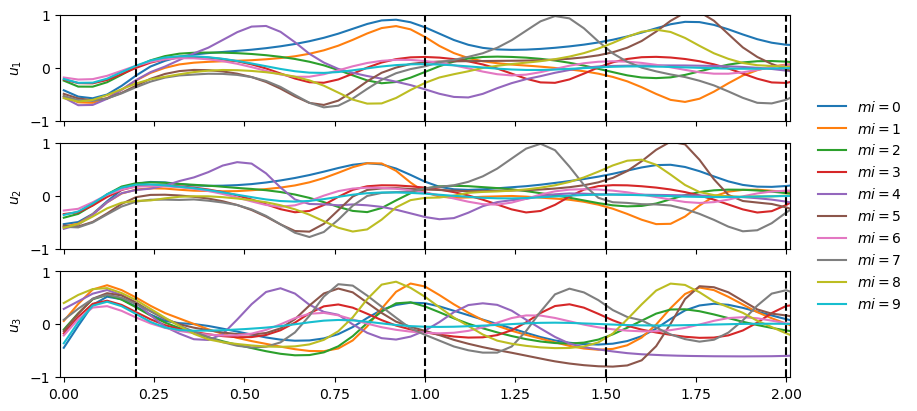

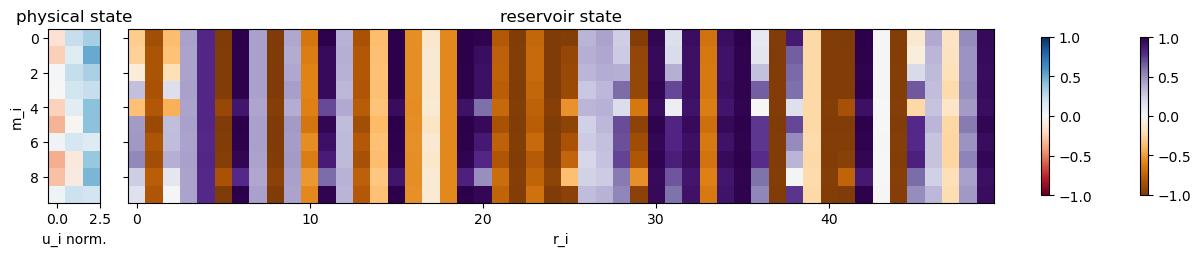

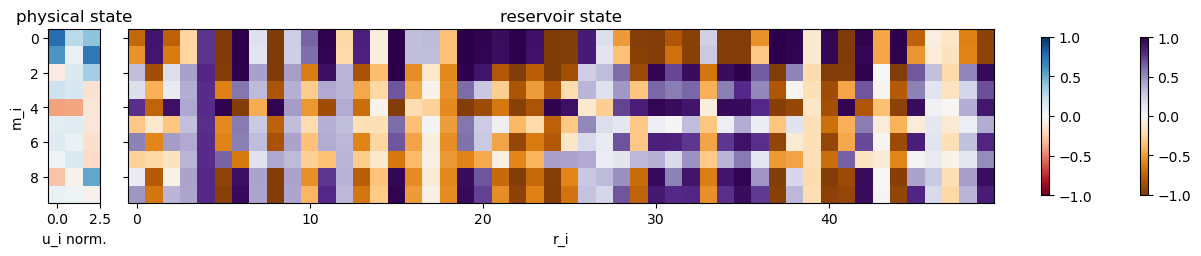

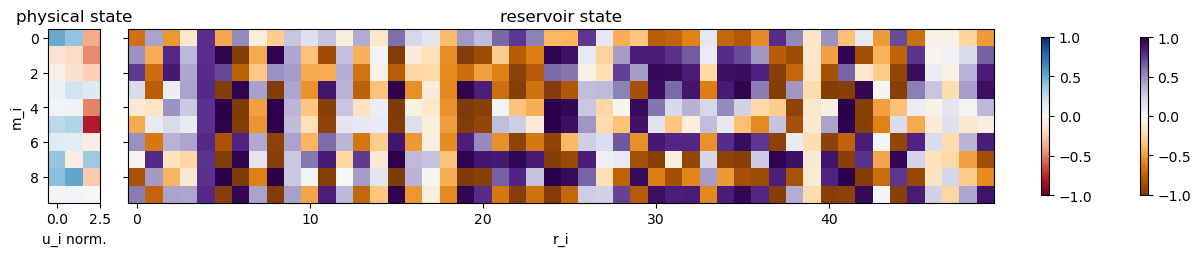

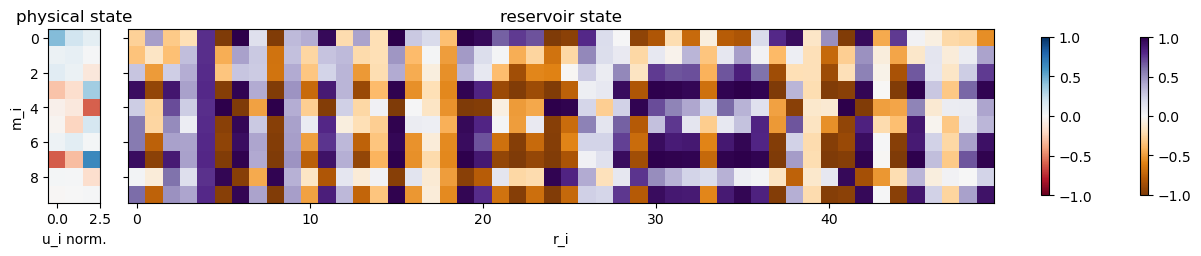

In [8]:
ensemble.model.visualize_config()